## 2) Import libraries

This cell gathers all required imports in one place.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.preprocessing import image

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 3) Download and locate the dataset

We download the dataset once, then point to its `data` folder.


In [2]:
# Download latest version
dataset_path = r"C:\Users\Lenovo\.cache\kagglehub\datasets\kritikseth\fruit-and-vegetable-image-recognition\versions\8\train"
print("Dataset path:", dataset_path)
print("Classes found:", os.listdir(dataset_path))

Dataset path: C:\Users\Lenovo\.cache\kagglehub\datasets\kritikseth\fruit-and-vegetable-image-recognition\versions\8\train
Classes found: ['apple', 'banana', 'bell pepper', 'cabbage']


## 4) Load the training and validation sets

We split the dataset into:
- **80% training**
- **20% validation**


In [3]:
IMG_SIZE = (224, 224)   # VGG19 standard input size
BATCH_SIZE = 32
SEED = 123

train_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_data.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Found 325 files belonging to 4 classes.
Using 260 files for training.
Found 325 files belonging to 4 classes.
Using 65 files for validation.
Class names: ['apple', 'banana', 'bell pepper', 'cabbage']
Number of classes: 4


## 5) Preprocess data for VGG19

VGG19 expects images to be preprocessed using `preprocess_input(...)` instead of simple `1/255` scaling.
We also cache and prefetch the datasets to improve performance.


In [4]:
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.map(lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y))
val_data = val_data.map(lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y))

train_data = train_data.cache().prefetch(AUTOTUNE)
val_data = val_data.cache().prefetch(AUTOTUNE)

## 6) Build the VGG19 model

We use **VGG19 pretrained on ImageNet** as a feature extractor, then add a small classification head for our dataset.


In [5]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras import layers, models

base_model = VGG19(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)



## 7) Compile the model

We use:
- **Adam** optimizer
- **Categorical cross-entropy** loss
- **Accuracy** as the main metric


In [6]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,090,564 (76.64 MB)

 Trainable params: 66,180 (258.52 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

## 8) Train the model


In [7]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
    
)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - accuracy: 0.5077 - loss: 4.6935 - val_accuracy: 0.8923 - val_loss: 0.4027
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 37s 4s/step - accuracy: 0.8962 - loss: 0.5925 - val_accuracy: 0.9692 - val_loss: 0.1440
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 35s 4s/step - accuracy: 0.9731 - loss: 0.1349 - val_accuracy: 0.9538 - val_loss: 0.1399
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.9846 - loss: 0.0930 - val_accuracy: 0.9538 - val_loss: 0.1178
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 37s 4s/step - accuracy: 0.9923 - loss: 0.0144 - val_accuracy: 0.9692 - val_loss: 0.1087
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 37s 4s/step - accuracy: 0.9731 - loss: 0.0862 - val_accuracy: 0.9846 - val_loss: 0.0827
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 37s 4s/step - accuracy: 0.9885 - loss: 0.0614 - val_accuracy: 0.9846 - val_loss: 0.0729
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 36s 4s/step - accuracy: 0.9962 - loss: 0.0287 - val_accuracy: 0.9846 - val_loss: 0.0734
Epoch 9/

## 9) Plot training and validation performance


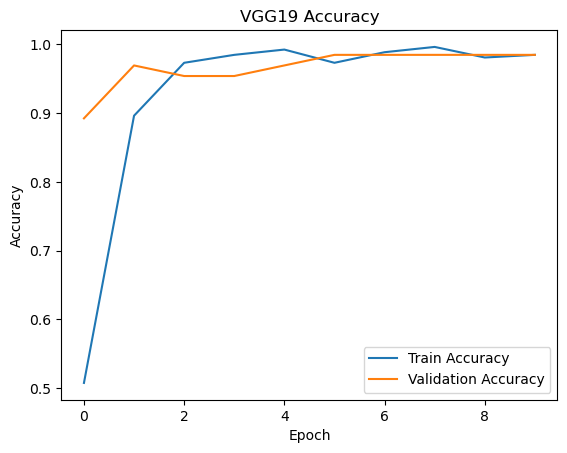

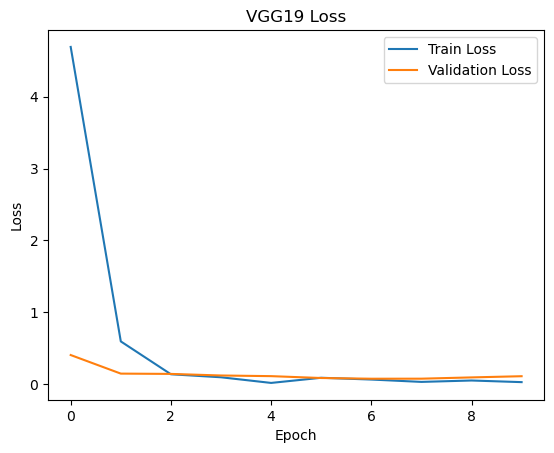

In [8]:
plt.figure()
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("VGG19 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("VGG19 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 10) Classification report and confusion matrix


              precision    recall  f1-score   support

       apple       0.94      1.00      0.97        15
      banana       1.00      0.94      0.97        18
 bell pepper       1.00      1.00      1.00        16
     cabbage       1.00      1.00      1.00        16

    accuracy                           0.98        65
   macro avg       0.98      0.99      0.98        65
weighted avg       0.99      0.98      0.98        65



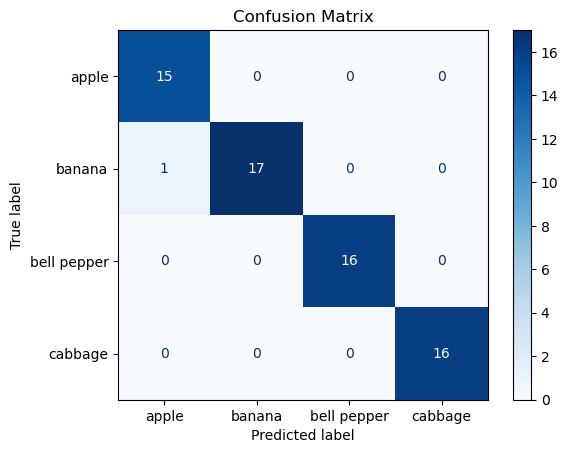

In [9]:
y_true = []
y_pred = []

for images, labels in val_data:
    predictions = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

## 11) Predict a new image

Update `img_path` to test any image you want.


In [10]:
img_path = r"C:\Users\Lenovo\.cache\kagglehub\datasets\kritikseth\fruit-and-vegetable-image-recognition\versions\8\test\cabbage\Image_1.jpg"

img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array.astype(np.float32))

prediction = model.predict(img_array, verbose=0)[0]
predicted_index = np.argmax(prediction)

print("Predicted class:", class_names[predicted_index])
print("Class probabilities:")
for name, prob in zip(class_names, prediction):
    print(f"{name}: {prob:.4f}")

Predicted class: cabbage
Class probabilities:
apple: 0.0000
banana: 0.0000
bell pepper: 0.0000
cabbage: 1.0000
